# Functions for later use

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_epoch_metrics(root_dir) -> pd.DataFrame:
    """
    Scan `root_dir` recursively for files named like:
        metrics_mean_epoch_<N>.csv
        metrics_std_epoch_<N>.csv

    Each CSV must have exactly 2 columns:
        - col 0: metric name (string)
        - col 1: value (numeric)

    For each epoch N, the function:
        - reads the corresponding mean and std files
        - appends "_mean" or "_std" to each metric name
        - constructs one row per epoch with all metrics

    Returns
    -------
    pd.DataFrame
        Index: epoch (int)
        Columns: <metric>_mean, <metric>_std, ...
    """
    root = Path(root_dir)

    # Regex to extract kind ("mean" or "std") and epoch number from filename
    pattern = re.compile(r"metrics_(mean|std)_epoch_(\d+)\.csv$")

    # Nested dict: epoch -> { column_name: value, ... }
    epoch_data = {}

    for csv_path in root.rglob("metrics_*_epoch_*.csv"):
        match = pattern.search(csv_path.name)
        if not match:
            continue  # skip non-matching files that just happen to look similar

        kind, epoch_str = match.groups()
        epoch = int(epoch_str)

        # Read file: two columns (metric, value)
        df = pd.read_csv(csv_path, header=0, names=["metric", "value"])

        # Initialize dict for this epoch if needed
        if epoch not in epoch_data:
            epoch_data[epoch] = {}

        # For each metric, create column `<metric>_<kind>`
        suffix = "_mean" if kind == "mean" else "_std"
        for _, row in df.iterrows():
            metric_name = str(row["metric"])
            col_name = f"{metric_name}{suffix}"
            epoch_data[epoch][col_name] = row["value"]

    # Convert dict-of-dicts into DataFrame
    rows = []
    for epoch, metrics in epoch_data.items():
        row = {"epoch": epoch}
        row.update(metrics)
        rows.append(row)

    if not rows:
        # No matching files -> return empty DataFrame with just an epoch index
        return pd.DataFrame(columns=[])

    result = pd.DataFrame(rows)
    result = result.sort_values("epoch")
    return result

def plot_all_metrics_with_std(df, title="Metrics per Epoch (mean ± std)", subtitle=""):
    """
    Plot MAE, MSE, PSNR, SSIM in a 2×2 grid.
    For each metric, draw:
        - mean line (<metric>_mean)
        - std band (mean ± std)

    The DataFrame must contain columns:
        epoch,
        MAE_mean, MAE_std,
        MSE_mean, MSE_std,
        PSNR_mean, PSNR_std,
        SSIM_mean, SSIM_std.
    """

    metrics = ["MAE", "MSE", "PSNR", "SSIM"]

    # Validate columns
    for m in metrics:
        if f"{m}_mean" not in df.columns or f"{m}_std" not in df.columns:
            raise ValueError(f"DataFrame must contain '{m}_mean' and '{m}_std'")

    # Sort to ensure correct order
    df_sorted = df.sort_values("epoch")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True)

    for ax, metric in zip(axes.flatten(), metrics):
        mean_col = f"{metric}_mean"
        std_col = f"{metric}_std"

        epochs = df_sorted["epoch"].values
        means = df_sorted[mean_col].values
        stds = df_sorted[std_col].values

        ax.plot(epochs, means, label=f"{metric} mean")
        ax.fill_between(
            epochs,
            means - stds,
            means + stds,
            alpha=0.3,
            label=f"{metric} ± std",
        )

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Value")
        ax.grid(True)
        ax.legend()

    # Main title
    fig.suptitle(title, fontsize=18, y=0.98)

    # Subtitle
    fig.text(0.5, 0.94, subtitle, ha="center", fontsize=11)

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

def parse_options_file(path):
    """
    Parse an options text file of the form:

        key: value [default: something]

    Returns a dict mapping option names to parsed Python values.
    """
    opts = {}
    pattern = re.compile(r"^\s*([A-Za-z0-9_]+)\s*:\s*(.*?)\s*(?:\[default:.*)?$")

    def convert(value):
        v = value.strip()
        # Handle booleans
        if v.lower() in ("true", "false"):
            return v.lower() == "true"
        # Handle numbers and inf
        if v.lower() == "inf":
            return float("inf")
        # Try int
        try:
            return int(v)
        except ValueError:
            pass
        # Try float
        try:
            return float(v)
        except ValueError:
            pass
        # Return raw string
        return v

    with open(path, "r") as f:
        for line in f:
            m = pattern.match(line)
            if m:
                key, val = m.group(1), m.group(2)
                opts[key] = convert(val)

    return opts

def load_df_and_region(name):
    """
    Load the epoch metrics DataFrame and derive a human-readable region name
    for a given experiment 'name'.
    """
    valid_logs_dir = f"/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/100results/{name}/val_epoch_metrics/"
    opt_path = f"/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/8checkpoints/{name}/val_opt.txt"

    df = load_epoch_metrics(valid_logs_dir)
    opts = parse_options_file(opt_path)

    region = opts['dataroot'].split('/')[-3]
    if region.startswith("6materialized"):
        region = "Full Body"

    # Recoding dictionary for consistent region names
    region_recode = {
        "AB": "Abdomen",
        "HN": "Head-Neck",
        "TH": "Thorax",
        "pelvis": "Pelvis",
        "brain": "Brain"
    }

    region = region_recode.get(region, region)

    return df, region, opts


def plot_from_name(name):
    df, region, opts = load_df_and_region(name)

    plot_all_metrics_with_std(
        df,
        title="Validation Performance",
        subtitle=f"{opts['model']} on {region}, n={opts['num_test']} slices"
    )


def find_best_checkpoint_per_metric(df, metric, max_epoch=None):
    """
    Find the epoch with the best value for a given metric.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with columns: epoch, <metric>_mean, etc.
    metric : str
        One of "MAE", "MSE", "PSNR", "SSIM"
    max_epoch : int, optional
        Maximum epoch to consider

    Returns
    -------
    tuple
        (best_epoch, best_value) where best is defined as:
        - minimum for MAE, MSE
        - maximum for PSNR, SSIM
    """
    df_sorted = df.sort_values("epoch").copy()

    if max_epoch:
        df_sorted = df_sorted[df_sorted["epoch"] <= max_epoch]

    mean_col = f"{metric}_mean"
    if mean_col not in df_sorted.columns:
        return None, None

    # Filter out inf and NaN values for finding the best
    df_valid = df_sorted[np.isfinite(df_sorted[mean_col])]

    if df_valid.empty:
        return None, None

    # Minimize MAE and MSE, maximize PSNR and SSIM
    if metric in ["MAE", "MSE"]:
        idx = df_valid[mean_col].idxmin()
    else:  # PSNR, SSIM
        idx = df_valid[mean_col].idxmax()

    best_epoch = df_valid.loc[idx, "epoch"]
    best_value = df_valid.loc[idx, mean_col]

    return best_epoch, best_value


def plot_all_regions_mean(
    names,
    title="Validation Performance (mean only)",
    max_epoch=None,
    plot_name=False,
    exclude_epochs=None,
    cutoff_epoch=None,          # <-- NEW: epoch at which to draw the vertical cutoff line
    cutoff_kwargs=None          # <-- NEW: optional style overrides for the cutoff line
):
    """
    For the given list of experiment names, plot the mean curves of
    all regions together in a single 2×2 grid (MAE, MSE, PSNR, SSIM).
    Each subplot: one metric, all regions as separate lines.

    Additionally, marks the best checkpoint per metric with a point on the curve.

    Parameters
    ----------
    names : list of str
        List of experiment names to plot
    title : str, optional
        Main title for the figure
    max_epoch : int, optional
        Maximum epoch to plot
    plot_name : bool, optional
        If True, use experiment name in legend; if False, use region name
    exclude_epochs : dict, optional
        Dictionary mapping experiment name (or region name) to list of epochs to exclude.
        Example: {"thorax": [26], "Thorax": [26]}
        Can use either the raw name from `names` or the region name.
    cutoff_epoch : int or float, optional
        If provided, draws a single vertical dashed red line at this epoch
        in every subplot (spanning the full y-domain currently displayed).
    cutoff_kwargs : dict, optional
        Optional overrides passed to ax.axvline for the cutoff line.
        Defaults to {"color":"red","linestyle":"--","linewidth":2,"alpha":0.9}.
    """
    metrics = ["MAE", "MSE", "PSNR", "SSIM"]
    metrics_titles = {"MAE":"↓ MAE ↓", "MSE":"↓ MSE ↓", "PSNR":"↑ PSNR ↑", "SSIM":"↑ SSIM ↑"}

    if exclude_epochs is None:
        exclude_epochs = {}

    if cutoff_kwargs is None:
        cutoff_kwargs = {"color": "red", "linestyle": "--", "linewidth": 2, "alpha": 0.9}

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

    # Track total exclusions for footnote
    total_exclusions = 0
    exclusion_details = []

    # For each experiment/region, plot its mean line on each metric subplot
    for name in names:
        df, region, opts = load_df_and_region(name)
        df_sorted = df.sort_values("epoch").copy()

        # Determine which epochs to exclude for this experiment
        epochs_to_exclude = []

        # Check both the raw name and the region name in exclude_epochs
        for key in [name, region]:
            if key in exclude_epochs:
                epochs_to_exclude.extend(exclude_epochs[key])

        # Remove duplicates
        epochs_to_exclude = list(set(epochs_to_exclude))

        # Filter out excluded epochs
        if epochs_to_exclude:
            excluded_count = len(df_sorted[df_sorted["epoch"].isin(epochs_to_exclude)])
            if excluded_count > 0:
                total_exclusions += excluded_count
                label_for_exclusion = name if plot_name else region
                exclusion_details.append(
                    f"{label_for_exclusion} (epochs: {', '.join(map(str, sorted(epochs_to_exclude)))})"
                )

            df_sorted = df_sorted[~df_sorted["epoch"].isin(epochs_to_exclude)]

        if max_epoch:
            df_sorted = df_sorted[df_sorted["epoch"] <= max_epoch]

        epochs = df_sorted["epoch"].values

        for ax, metric in zip(axes.flatten(), metrics):
            mean_col = f"{metric}_mean"
            if mean_col not in df_sorted.columns:
                continue  # skip if this metric is missing

            # Filter out inf/NaN values for plotting
            valid_mask = np.isfinite(df_sorted[mean_col].values)
            plot_epochs = epochs[valid_mask]
            means = df_sorted[mean_col].values[valid_mask]

            label = name if plot_name else region

            # Plot the line
            line = ax.plot(plot_epochs, means, label=label)

            # Find and mark the best checkpoint for this metric (using filtered df)
            df_for_best = df_sorted[np.isfinite(df_sorted[mean_col])]
            best_epoch, best_value = find_best_checkpoint_per_metric(df_for_best, metric, max_epoch)
            if best_epoch is not None:
                # Plot marker with same color as line
                ax.plot(
                    best_epoch, best_value, 'o', color=line[0].get_color(),
                    markersize=8, markeredgewidth=1.5, markeredgecolor='white',
                    zorder=10
                )

    # Axis labels and titles (without individual legends)
    for ax, metric in zip(axes.flatten(), metrics):
        ax.set_title(metrics_titles[metric])
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric)
        ax.grid(True)

        # NEW: draw cutoff line (after plotting so autoscaling is already determined)
        if cutoff_epoch is not None:
            ax.axvline(cutoff_epoch, **cutoff_kwargs)

    # Collect handles and labels from the first subplot (all have the same legend)
    handles, labels = axes.flatten()[0].get_legend_handles_labels()

    # Create a single legend outside the subplots
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=True)

    fig.suptitle(title, fontsize=18, y=0.98)

    # Add footnote if there were exclusions
    if total_exclusions > 0:
        footnote_text = f"* {total_exclusions} epoch(s) excluded: {'; '.join(exclusion_details)}"
        fig.text(0.5, 0.01, footnote_text, ha="center", fontsize=9, style='italic', wrap=True)
        plt.tight_layout(rect=[0, 0.03, 0.95, 0.97])
    else:
        plt.tight_layout(rect=[0, 0, 0.95, 0.97])

    plt.show()


# Experiment 1: Validation

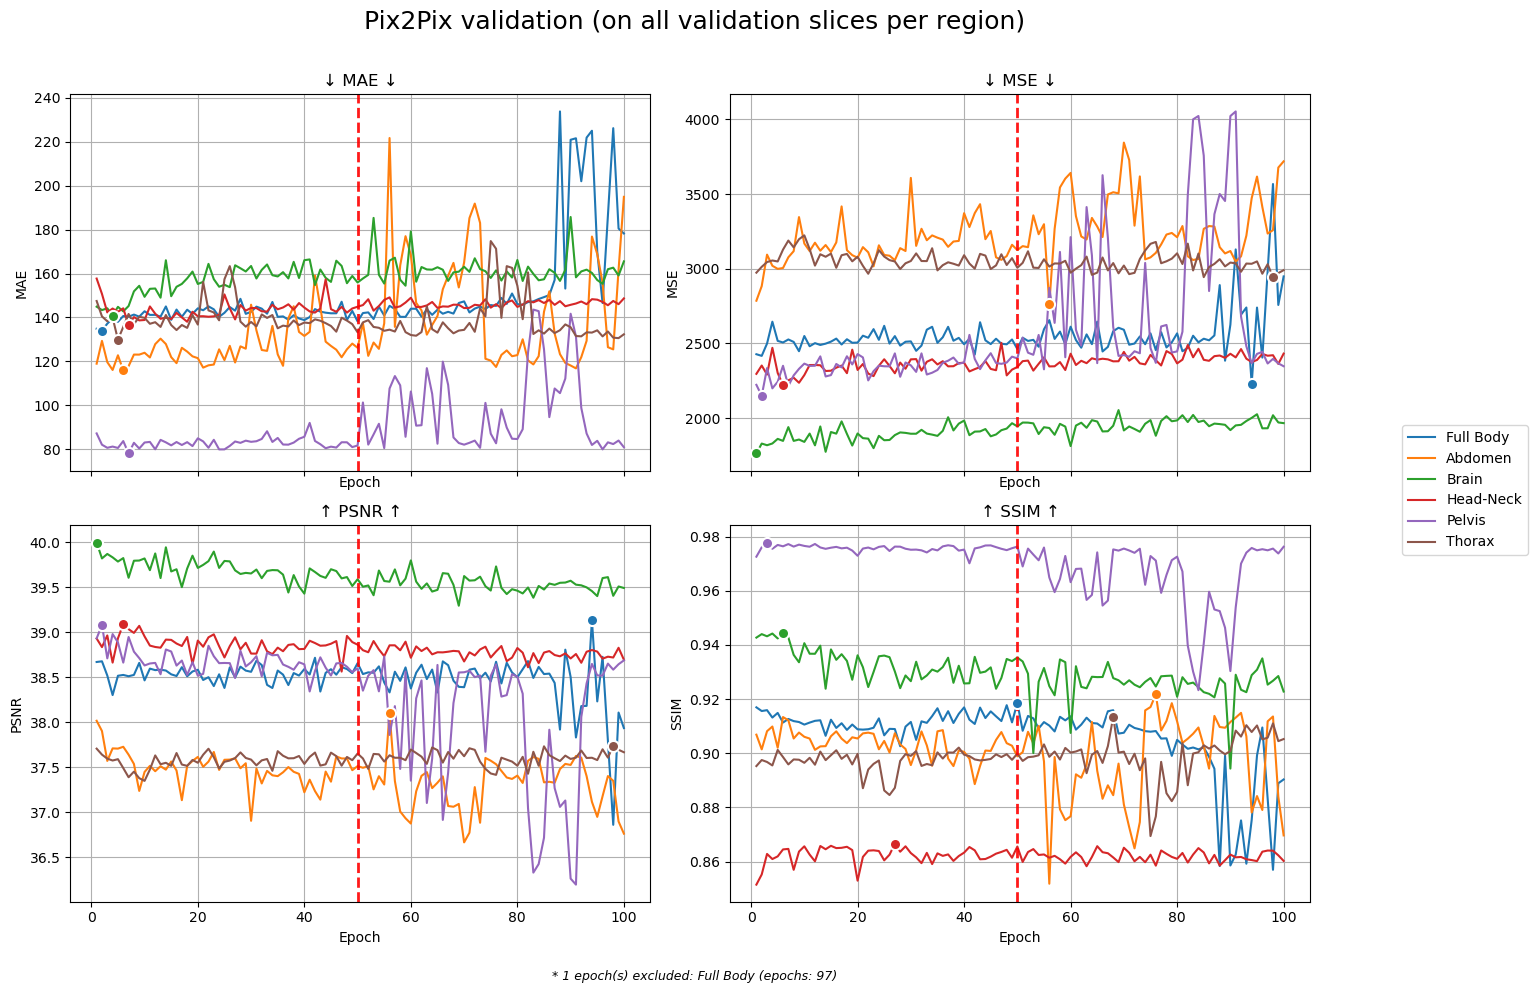

In [ ]:
names = ["pix2pix_synthrad_allregion_final", "pix2pix_synthrad_abdomen_final", "pix2pix_synthrad_brain_final", "pix2pix_synthrad_headneck_final", "pix2pix_synthrad_pelvis_final", "pix2pix_synthrad_thorax_final"]
plot_all_regions_mean(names, "Pix2Pix validation (on all validation slices per region)", max_epoch=100, cutoff_epoch=50, exclude_epochs={"Full Body": [97]})

# # can be used to plot std of validation results
# for name in names:
#     plot_from_name(name)

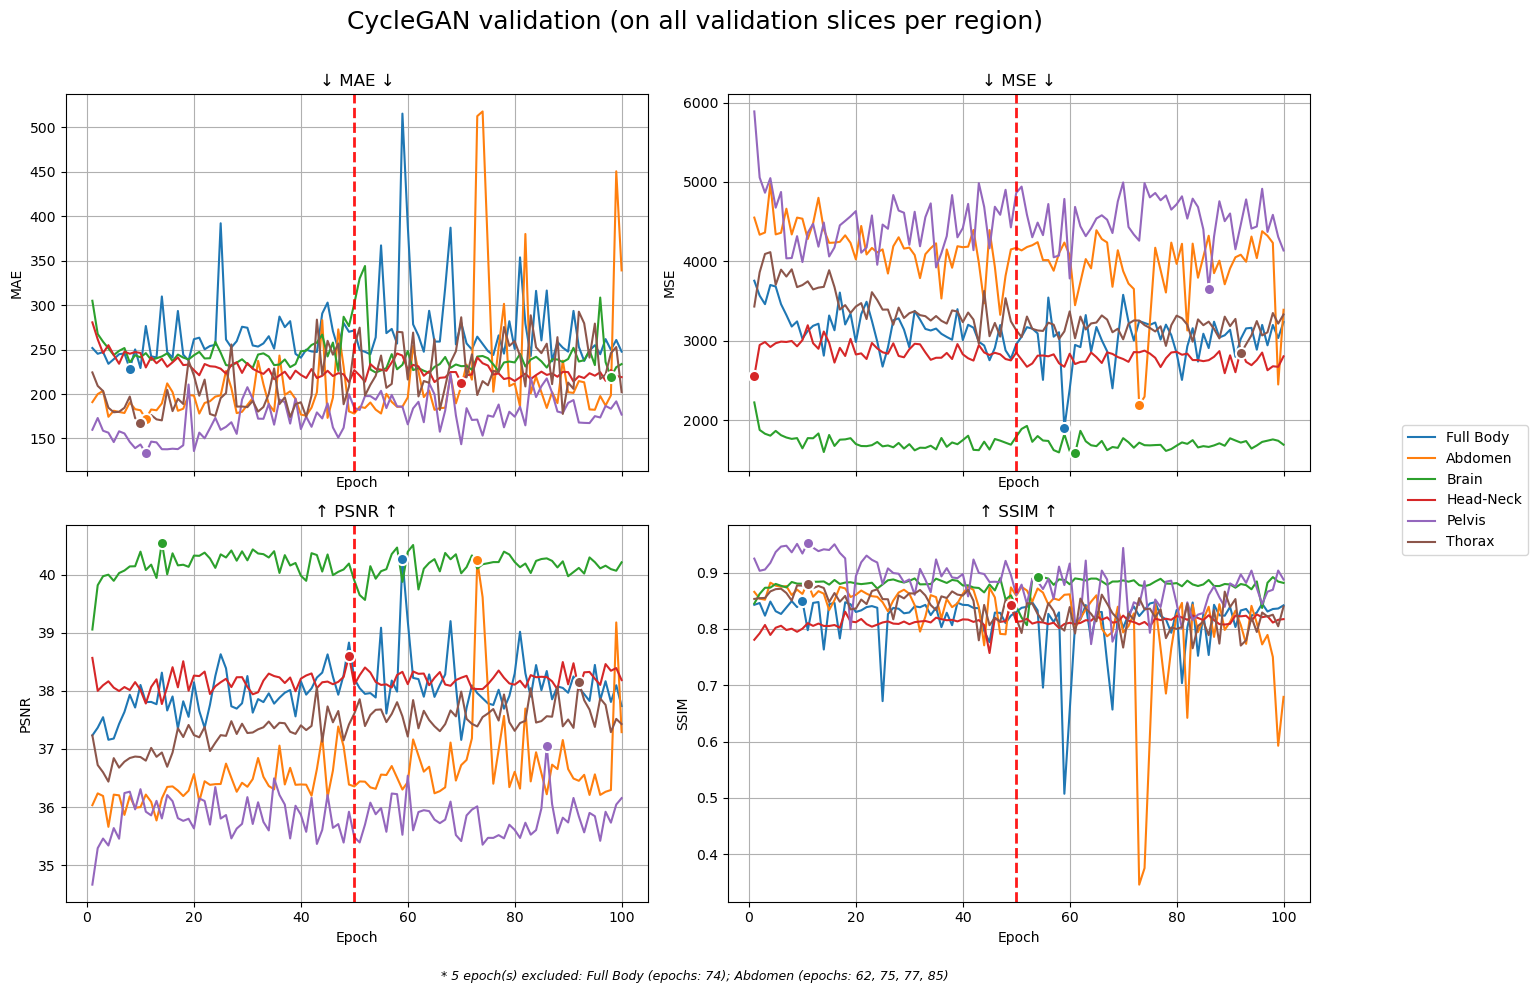

In [3]:
names = ["cyclegan_allregions_final", "cyclegan_abdomen_final", "cyclegan_brain_final", "cyclegan_head_neck_final", "cyclegan_pelvis_final", "cyclegan_thorax_final"]
plot_all_regions_mean(names, "CycleGAN validation (on all validation slices per region)", max_epoch=100, cutoff_epoch=50, exclude_epochs={"Full Body": [74], "Abdomen": [62, 75, 77, 85]})

# # can be used to plot std of validation results
# for name in names:
#     plot_from_name(name)

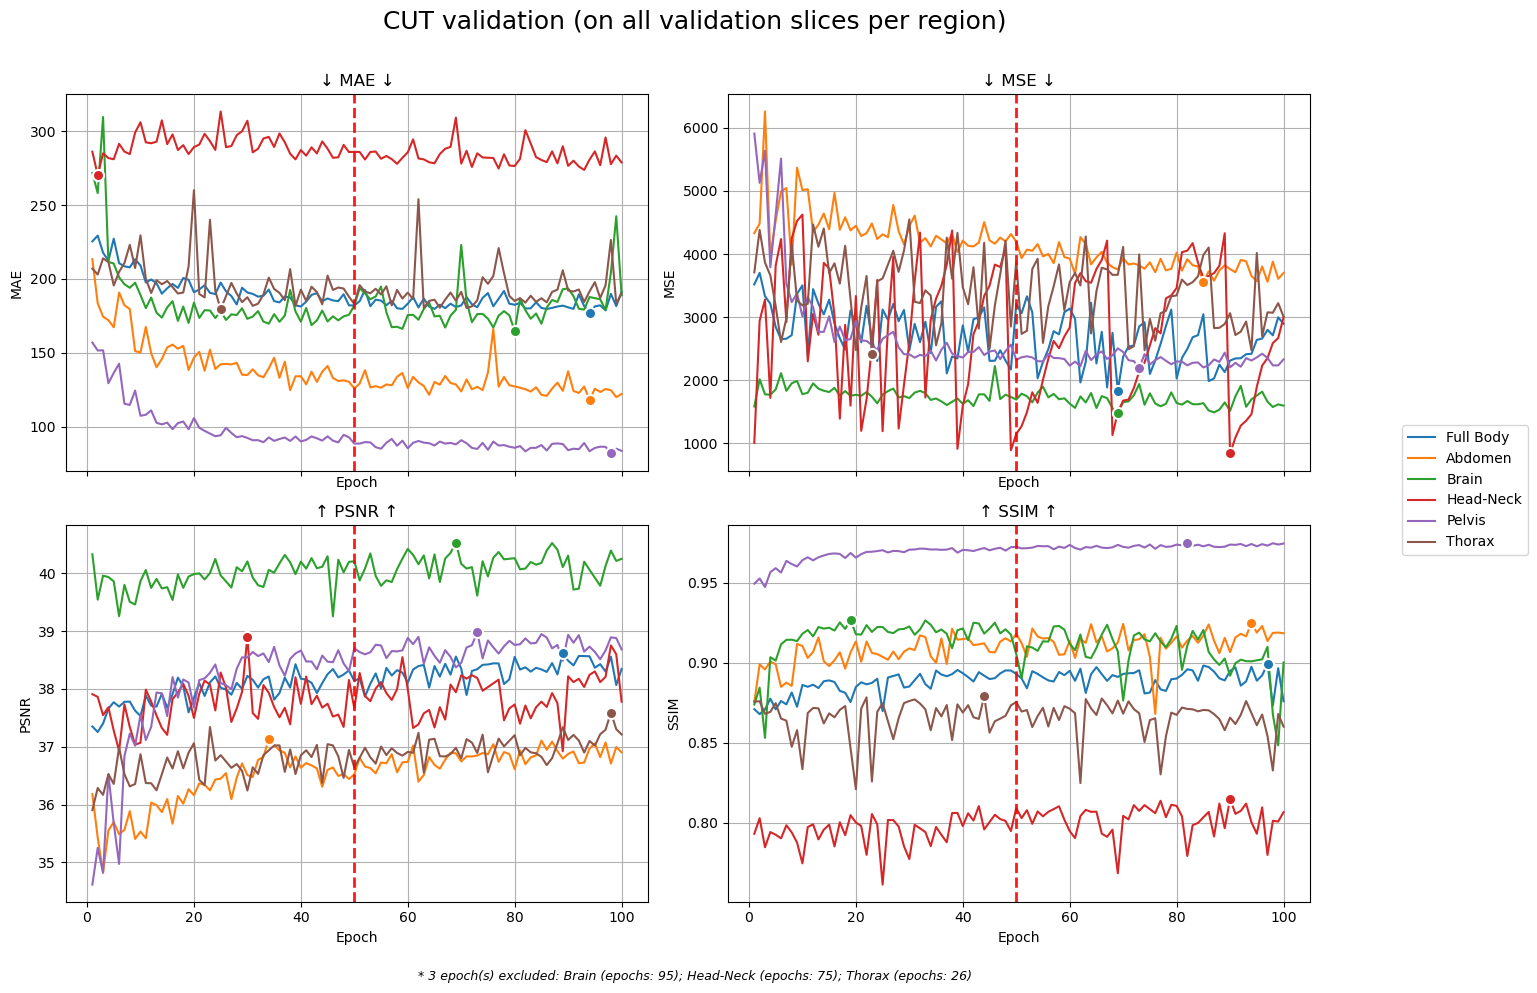

In [4]:
names = ["cut_synthrad_allregions_final", "cut_synthrad_abdomen_final", "cut_synthrad_brain_final", "cut_synthrad_HN_final", "cut_synthrad_pelvis_final", "cut_synthrad_TH_final"]
plot_all_regions_mean(names, "CUT validation (on all validation slices per region)", max_epoch=100, cutoff_epoch=50, exclude_epochs={"Thorax": [26], "Head-Neck": [75], "Brain": [95]})

# # can be used to plot std of validation results
# for name in names:
#     plot_from_name(name)

# Hyperparameter Tuning and Development Results

## Pix2Pix

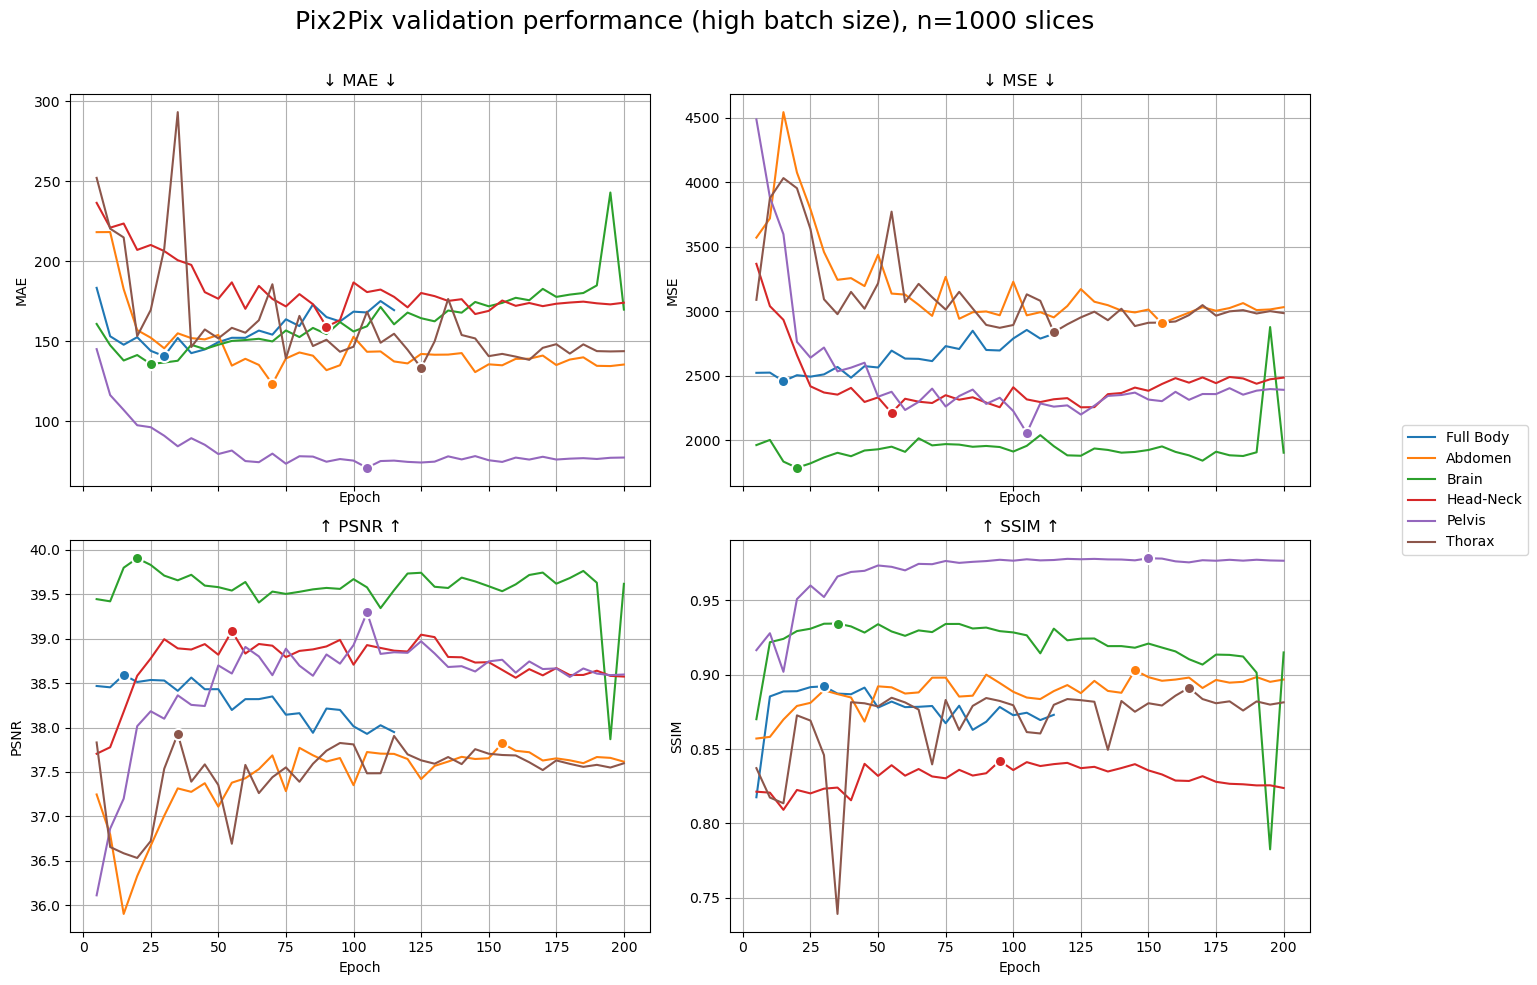

In [5]:
names = ["pix2pix_synthrad_allregions", "pix2pix_synthrad_abdomen", "pix2pix_synthrad_brain", "pix2pix_synthrad_head_neck", "pix2pix_synthrad_pelvis", "pix2pix_synthrad_thorax"]
plot_all_regions_mean(names, "Pix2Pix validation performance (high batch size), n=1000 slices")

FileNotFoundError: [Errno 2] No such file or directory: '/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/8checkpoints/pix2pix_synthrad_abdomen_sep_input_layers/val_opt.txt'

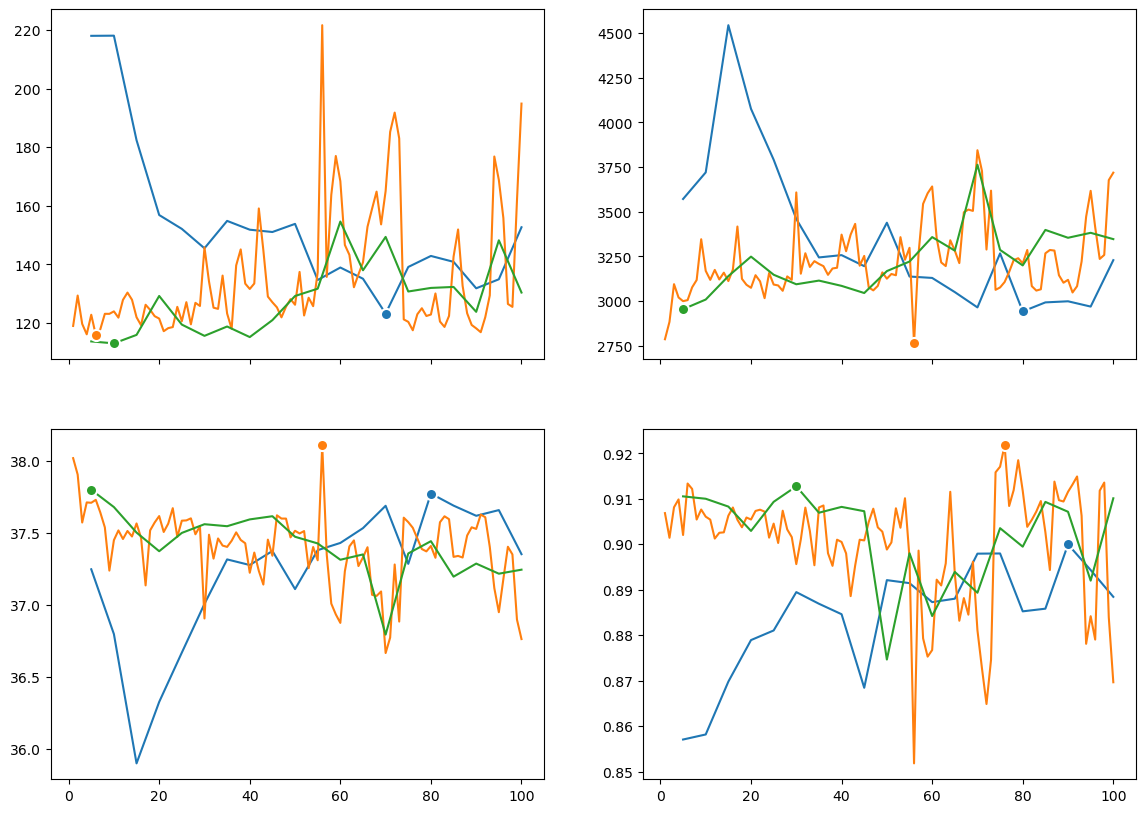

In [6]:
names = ["pix2pix_synthrad_abdomen", "pix2pix_synthrad_abdomen_final", "pix2pix_synthrad_abdomen_bs1", "pix2pix_synthrad_abdomen_sep_input_layers", "pix2pix_synthrad_abdomen_no_preproc"]
plot_all_regions_mean(names, "Pix2Pix validation performance, all n=2698 slices", max_epoch=100, plot_name=True)

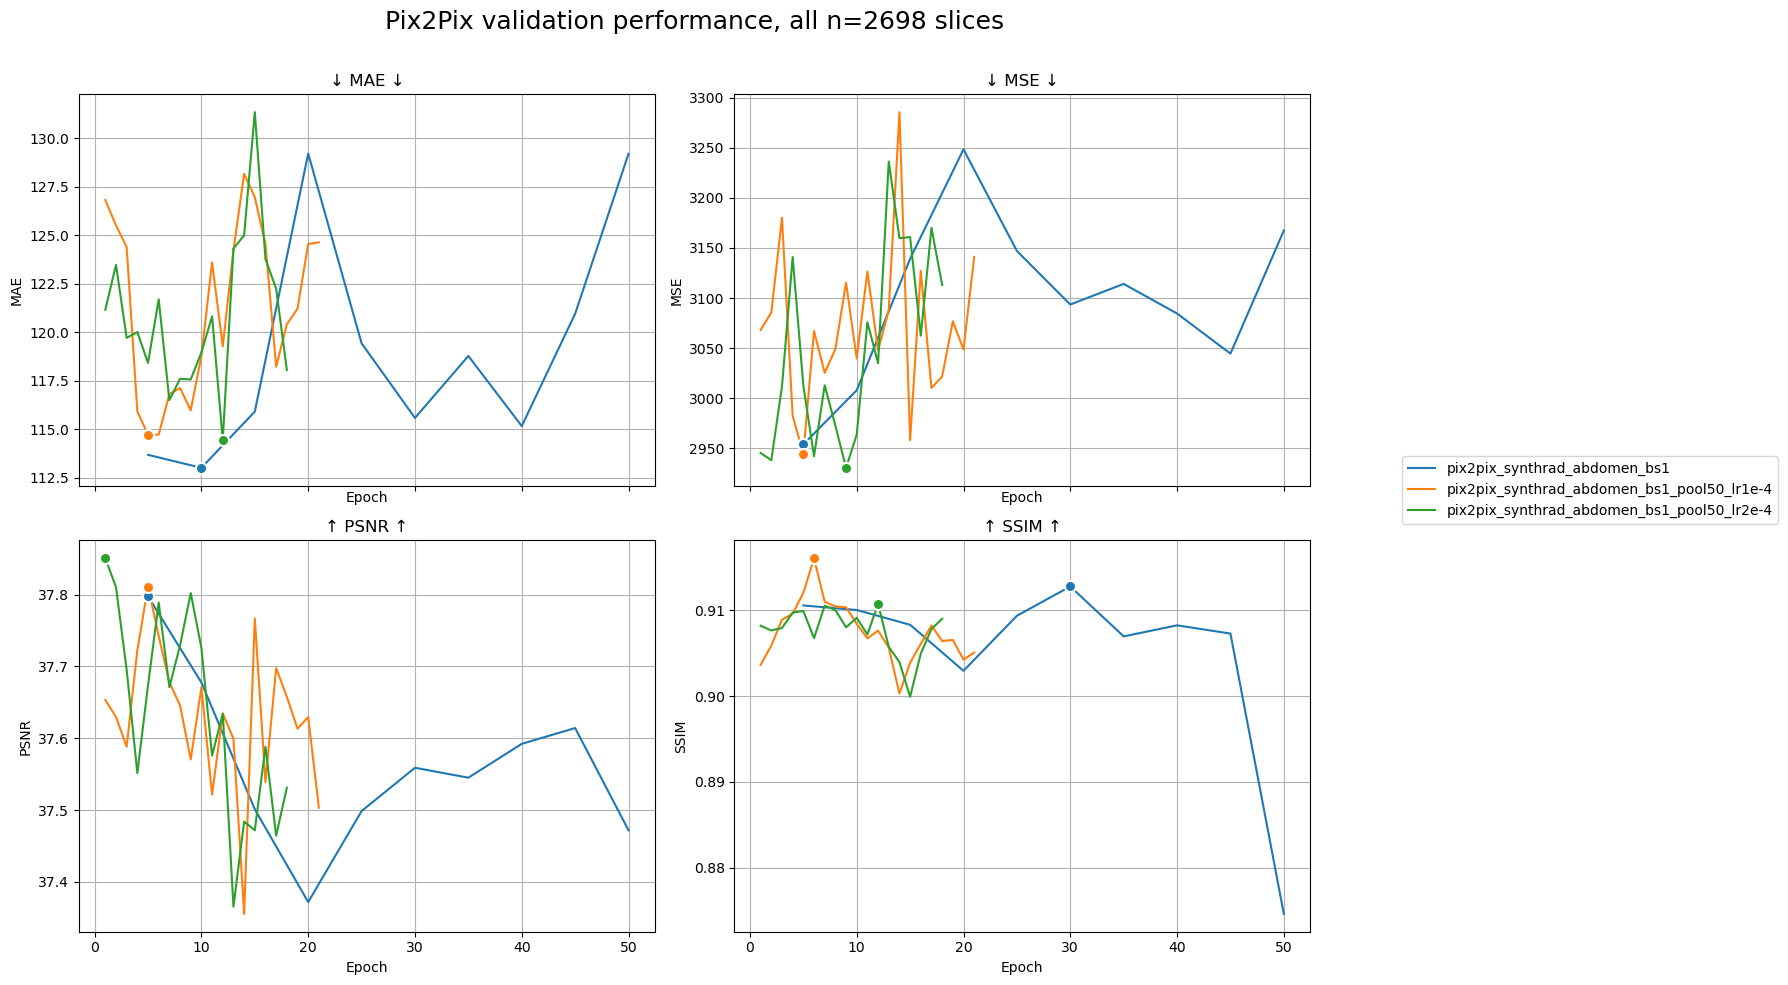

In [ ]:
names = ["pix2pix_synthrad_abdomen_bs1", "pix2pix_synthrad_abdomen_bs1_pool50_lr1e-4", "pix2pix_synthrad_abdomen_bs1_pool50_lr2e-4"]
plot_all_regions_mean(names, "Pix2Pix validation performance, all n=2698 slices", max_epoch=50, plot_name=True)

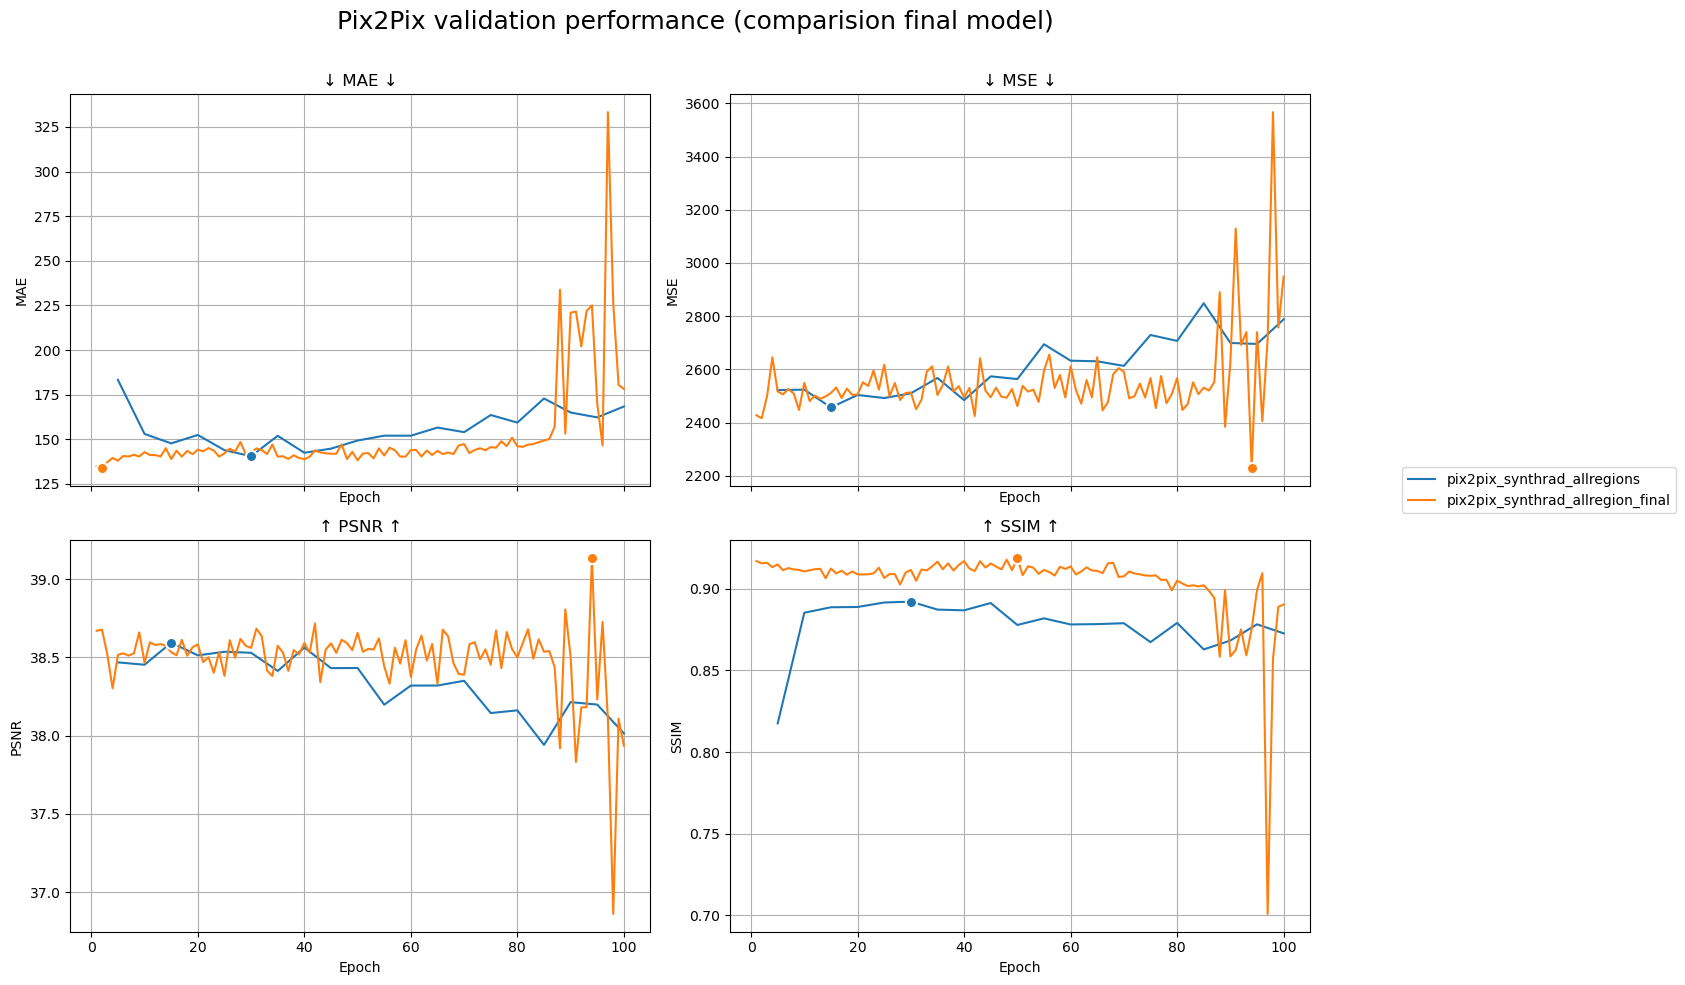

In [ ]:
names = ["pix2pix_synthrad_allregions", "pix2pix_synthrad_allregion_final"]
plot_all_regions_mean(names, "Pix2Pix validation performance (comparision final model)", max_epoch=100, plot_name=True)